# Ketahanan Modal Rp400.000 — Apakah Bisa MC? Seberapa Sering Modal Turun / Bertambah?

**Pertanyaan user**: dengan modal Rp400rb, apakah bisa terkena **MC (margin call)**? User ingin modal
**tetap hidup** di sekitar Rp400rb dan kalau bisa **bertambah terus**, walau kecil.

### Soal MC
**Margin call / likuidasi hanya terjadi pada trading dengan leverage** (margin/futures: meminjam dana exchange).
Strategi ini **spot tanpa leverage** — BTC dibeli dengan uang sendiri → exchange **tidak bisa** menutup paksa
posisi dan saldo **tidak bisa minus**. Yang tetap bisa terjadi: **nilai modal turun sementara** (drawdown).

Notebook ini mengukur drawdown itu dalam Rupiah untuk strategi 13 (BTC saja, filter H8b), dengan:
1. **Semua kemungkinan tanggal mulai** 2019-01 → 2025-06 (masa 12 bulan ke depan).
2. **Monte Carlo 10.000 jalur** 12 bulan (block bootstrap dari return harian historis).

*Kill switch* dari notebook 17: bot berhenti kalau modal ≤ **Rp280rb (−30%)**.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT)); sys.path.insert(0, str(PROJECT_ROOT / "notebooks"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from data_source.loader import load_symbol
from data_source.fear_greed import load_fear_greed_index
from research.single_position import Panel, BTC
from research.portfolio import run_portfolio

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
MODAL, KILL = 400_000, 280_000
P = Panel({BTC: load_symbol(BTC, "1d", "since2018")}, "2018-01-01", "2026-06-30")
fgi = load_fear_greed_index()["fng_value"].reindex(P.dates).ffill()
btc = P.close[BTC]
market = (btc > btc.rolling(100, min_periods=100).mean()) | (fgi.rolling(14).mean() > 50)
base = pd.DataFrame({BTC: market.astype(float)}, index=P.dates)
PORSI = {"porsi 40%": 0.4, "porsi 60%": 0.6, "porsi 100%": 1.0}
eqs = {k: run_portfolio(P, base * v, "2019-01-01", "2026-06-30", freq="M")[0] for k, v in PORSI.items()}
hold = run_portfolio(P, pd.DataFrame({BTC: 1.0}, index=P.dates), "2019-01-01", "2026-06-30", freq="M")[0]
eqs["buy & hold BTC (pembanding)"] = hold
print({k: f"total {e.iloc[-1] / e.iloc[0] - 1:+.0%}" for k, e in eqs.items()})

{'porsi 40%': 'total +407%', 'porsi 60%': 'total +910%', 'porsi 100%': 'total +3129%', 'buy & hold BTC (pembanding)': 'total +1444%'}


## 1. Semua kemungkinan tanggal mulai (masa 12 bulan)

Untuk **setiap hari** antara 2019-01-01 dan 2025-06-30 dianggap sebagai hari mulai dengan Rp400rb, lalu
dilihat 12 bulan ke depan: nilai terendah, dan nilai setelah 1/3/6/12 bulan.

In [2]:
def rolling_start(eq, horizon_days=365, step=1):
    rows = []
    idx = eq.index
    last_start = idx[-1] - pd.Timedelta(days=horizon_days)
    for i in range(0, len(idx), step):
        t0 = idx[i]
        if t0 > last_start:
            break
        path = eq.loc[t0:t0 + pd.Timedelta(days=horizon_days)] / eq.loc[t0] * MODAL
        def at(days):
            return path.loc[:t0 + pd.Timedelta(days=days)].iloc[-1]
        rows.append(dict(mulai=t0, terendah=path.min(), b1=at(30), b3=at(91), b6=at(182), b12=path.iloc[-1],
                         sentuh_kill=path.min() <= KILL))
    return pd.DataFrame(rows).set_index("mulai")

summary, rs_all = {}, {}
for name, eq in eqs.items():
    rs = rolling_start(eq)
    rs_all[name] = rs
    summary[name] = {
        "jumlah tanggal mulai": len(rs),
        "% akhir 1 bulan >= Rp400rb": (rs.b1 >= MODAL).mean(),
        "% akhir 3 bulan >= Rp400rb": (rs.b3 >= MODAL).mean(),
        "% akhir 6 bulan >= Rp400rb": (rs.b6 >= MODAL).mean(),
        "% akhir 12 bulan >= Rp400rb": (rs.b12 >= MODAL).mean(),
        "median nilai 12 bulan": rs.b12.median(),
        "nilai 12 bulan terburuk": rs.b12.min(),
        "titik terendah (median)": rs.terendah.median(),
        "titik terendah (terburuk)": rs.terendah.min(),
        "% pernah turun < Rp360rb (-10%)": (rs.terendah < 360_000).mean(),
        "% pernah turun < Rp320rb (-20%)": (rs.terendah < 320_000).mean(),
        "% sentuh kill switch Rp280rb": rs.sentuh_kill.mean(),
    }
S = pd.DataFrame(summary)
out = S.copy().astype(object)
for i in S.index:
    out.loc[i] = S.loc[i].map(lambda v: f"{int(v):,}" if i == "jumlah tanggal mulai" else
                              (f"{v:.0%}" if i.startswith("%") else f"Rp{v:,.0f}"))
out

,porsi 40%,porsi 60%,porsi 100%,buy & hold BTC (pembanding)
jumlah tanggal mulai,"2,373","2,373","2,373","2,373"
% akhir 1 bulan >= Rp400rb,65%,65%,65%,59%
% akhir 3 bulan >= Rp400rb,61%,61%,60%,63%
% akhir 6 bulan >= Rp400rb,72%,71%,70%,69%
% akhir 12 bulan >= Rp400rb,85%,84%,82%,68%
median nilai 12 bulan,"Rp475,858","Rp510,845","Rp575,551","Rp618,685"
nilai 12 bulan terburuk,"Rp332,971","Rp303,136","Rp250,099","Rp95,136"
titik terendah (median),"Rp385,738","Rp378,422","Rp361,589","Rp322,610"
titik terendah (terburuk),"Rp330,302","Rp301,924","Rp243,347","Rp95,136"
% pernah turun < Rp360rb (-10%),9%,26%,49%,66%


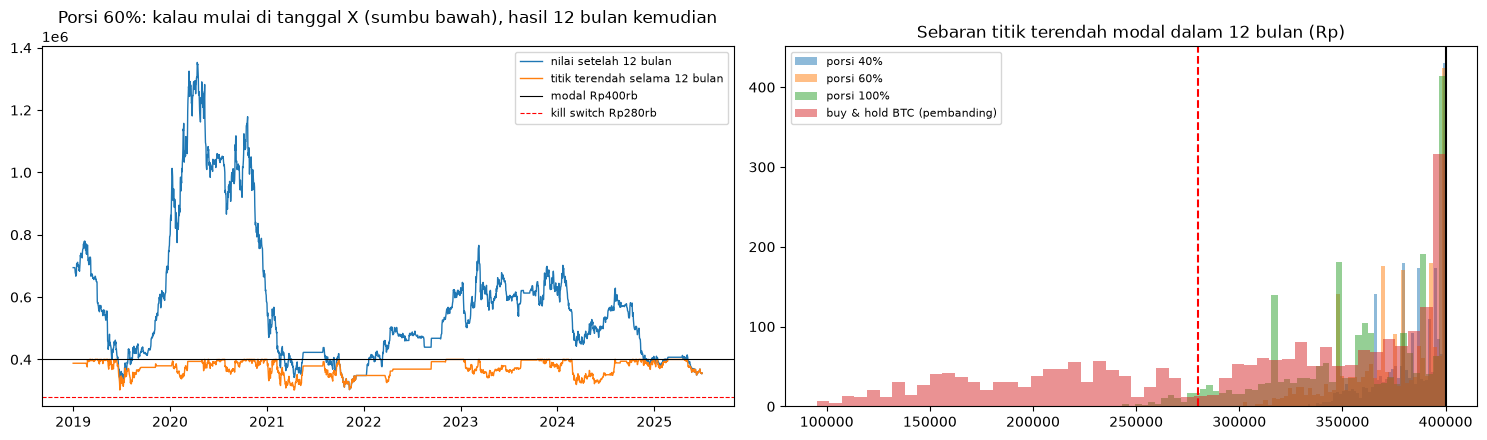

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
rs = rs_all["porsi 60%"]
axes[0].plot(rs.index, rs.b12, lw=1, label="nilai setelah 12 bulan")
axes[0].plot(rs.index, rs.terendah, lw=1, label="titik terendah selama 12 bulan")
axes[0].axhline(MODAL, color="black", lw=0.8, label="modal Rp400rb")
axes[0].axhline(KILL, color="red", ls="--", lw=0.8, label="kill switch Rp280rb")
axes[0].set_title("Porsi 60%: kalau mulai di tanggal X (sumbu bawah), hasil 12 bulan kemudian"); axes[0].legend(fontsize=8)
for name in ("porsi 40%", "porsi 60%", "porsi 100%", "buy & hold BTC (pembanding)"):
    axes[1].hist(rs_all[name].terendah, bins=50, alpha=0.5, label=name)
axes[1].axvline(KILL, color="red", ls="--"); axes[1].axvline(MODAL, color="black")
axes[1].set_title("Sebaran titik terendah modal dalam 12 bulan (Rp)"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 2. Monte Carlo 10.000 jalur × 12 bulan

Return harian historis strategi (2019–2026) diacak ulang dalam **blok 30 hari** (menjaga pola tren/crash
berurutan), membentuk 10.000 kemungkinan masa depan 12 bulan dari Rp400rb.

In [4]:
def monte_carlo(eq, n_paths=10_000, horizon=365, block=30, seed=7):
    r = eq.pct_change().dropna().to_numpy()
    rng = np.random.default_rng(seed)
    n_blocks = int(np.ceil(horizon / block))
    starts = rng.integers(0, len(r) - block, size=(n_paths, n_blocks))
    paths = r[starts[:, :, None] + np.arange(block)].reshape(n_paths, -1)[:, :horizon]
    val = MODAL * np.cumprod(1 + paths, axis=1)
    return val

mc_rows, mc_vals = {}, {}
for name, eq in eqs.items():
    v = monte_carlo(eq)
    mc_vals[name] = v
    end, low = v[:, -1], v.min(axis=1)
    mc_rows[name] = {
        "% jalur untung setelah 12 bulan": (end > MODAL).mean(),
        "median nilai 12 bulan": np.median(end),
        "5% terburuk nilai 12 bulan": np.percentile(end, 5),
        "1% terburuk nilai 12 bulan": np.percentile(end, 1),
        "median titik terendah": np.median(low),
        "% pernah turun < Rp320rb (-20%)": (low < 320_000).mean(),
        "% sentuh kill switch Rp280rb": (low <= KILL).mean(),
        "% berakhir < Rp300rb": (end < 300_000).mean(),
    }
M = pd.DataFrame(mc_rows)
out = M.copy().astype(object)
for i in M.index:
    out.loc[i] = M.loc[i].map(lambda v: f"{v:.1%}" if i.startswith("%") else f"Rp{v:,.0f}")
out

,porsi 40%,porsi 60%,porsi 100%,buy & hold BTC (pembanding)
% jalur untung setelah 12 bulan,86.0%,85.3%,83.5%,72.4%
median nilai 12 bulan,"Rp490,808","Rp535,726","Rp622,104","Rp585,492"
5% terburuk nilai 12 bulan,"Rp363,178","Rp343,567","Rp302,217","Rp201,264"
1% terburuk nilai 12 bulan,"Rp327,395","Rp293,833","Rp234,856","Rp127,600"
median titik terendah,"Rp381,765","Rp372,437","Rp353,358","Rp317,197"
% pernah turun < Rp320rb (-20%),2.2%,10.0%,28.4%,51.1%
% sentuh kill switch Rp280rb,0.1%,1.8%,12.0%,36.1%
% berakhir < Rp300rb,0.2%,1.3%,4.8%,14.8%


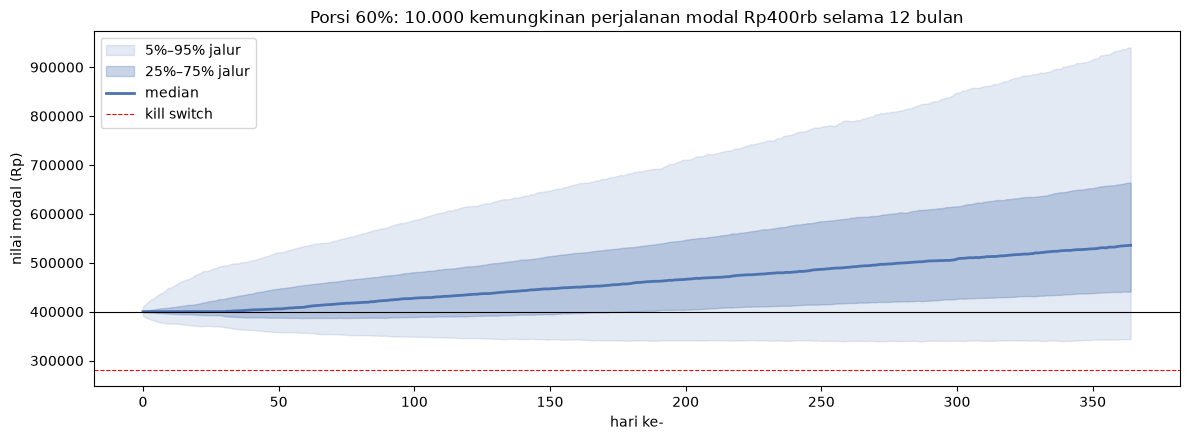

In [5]:
v = mc_vals["porsi 60%"]
fig, ax = plt.subplots(figsize=(12, 4.5))
days = np.arange(v.shape[1])
for q, a in ((5, 0.15), (25, 0.3)):
    ax.fill_between(days, np.percentile(v, q, axis=0), np.percentile(v, 100 - q, axis=0), alpha=a, color="#4C72B0",
                    label=f"{q}%–{100 - q}% jalur")
ax.plot(days, np.median(v, axis=0), color="#4C72B0", lw=2, label="median")
ax.axhline(MODAL, color="black", lw=0.8); ax.axhline(KILL, color="red", ls="--", lw=0.8, label="kill switch")
ax.set_xlabel("hari ke-"); ax.set_ylabel("nilai modal (Rp)")
ax.set_title("Porsi 60%: 10.000 kemungkinan perjalanan modal Rp400rb selama 12 bulan"); ax.legend()
plt.tight_layout(); plt.show()

## Kesimpulan

### MC (margin call): **tidak mungkin terjadi**
Strategi spot tanpa leverage → tidak ada pinjaman, tidak ada likuidasi, saldo tidak bisa minus.
Risiko yang tersisa hanya **nilai modal turun sementara** + risiko non-pasar (exchange bermasalah, bug bot,
API key bocor, stablecoin kehilangan patokan $1).

### Seberapa aman modal Rp400rb? (12 bulan ke depan)
| | **Porsi 40%** | **Porsi 60%** | Porsi 100% | Buy & hold BTC |
|---|---|---|---|---|
| Mulai kapan pun 2019–2025: % tetap ≥ Rp400rb setelah 12 bulan | **85%** | **84%** | 82% | 68% |
| Median nilai setelah 12 bulan | Rp476rb | **Rp511rb** | Rp576rb | Rp619rb |
| Titik terendah paling buruk (semua tanggal mulai) | **Rp330rb** | Rp302rb | Rp243rb | Rp95rb |
| Pernah menyentuh kill switch Rp280rb | **0%** | **0%** | 4% | 38% |
| Monte Carlo: % jalur untung setelah 12 bulan | 86% | 85% | 84% | 72% |
| Monte Carlo: 5% skenario terburuk | Rp363rb | Rp344rb | Rp302rb | Rp201rb |
| Monte Carlo: peluang sentuh Rp280rb | 0.1% | 1.8% | 12% | 36% |

### Yang perlu dipahami
- **Jangka pendek sering naik-turun**: setelah 1 bulan, hanya ±65% tanggal mulai yang nilainya ≥ Rp400rb;
  setelah 3 bulan ±61%. Artinya **1 dari 3 bulan bisa berakhir di bawah modal** — normal.
- **Jangka panjang cenderung bertambah**: setelah 12 bulan ±85% kemungkinan di atas Rp400rb.
- "Modal selalu ≥ Rp400rb setiap saat" **tidak bisa dijamin**; yang bisa: penurunan **terbatas** (porsi 60%:
  median titik terendah ±Rp378rb, terburuk historis ±Rp302rb).

### Rekomendasi untuk tujuan "modal tetap hidup & bertambah pelan"
- **Porsi 60%** (order ±$14.7): titik terendah historis Rp302rb, tidak pernah sentuh kill switch, median
  12 bulan ±Rp511rb. **Atau porsi 40%** (order ±$9.8, masih di atas minimum $5) kalau ingin lebih tenang:
  titik terendah historis Rp330rb, median 12 bulan ±Rp476rb.
- Pertahankan **kill switch Rp280rb** sebagai pengaman terakhir (bug/kejadian luar biasa).
- Nilai hasil **per 6–12 bulan**, bukan per hari/bulan.